
image 1/1 /home/edward/Python/Java62/python-ai-62/05_yolo_intro/street.jpg: 640x512 5 persons, 1 bicycle, 2 cars, 1 backpack, 3 suitcases, 43.8ms
Speed: 1.8ms preprocess, 43.8ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 512)


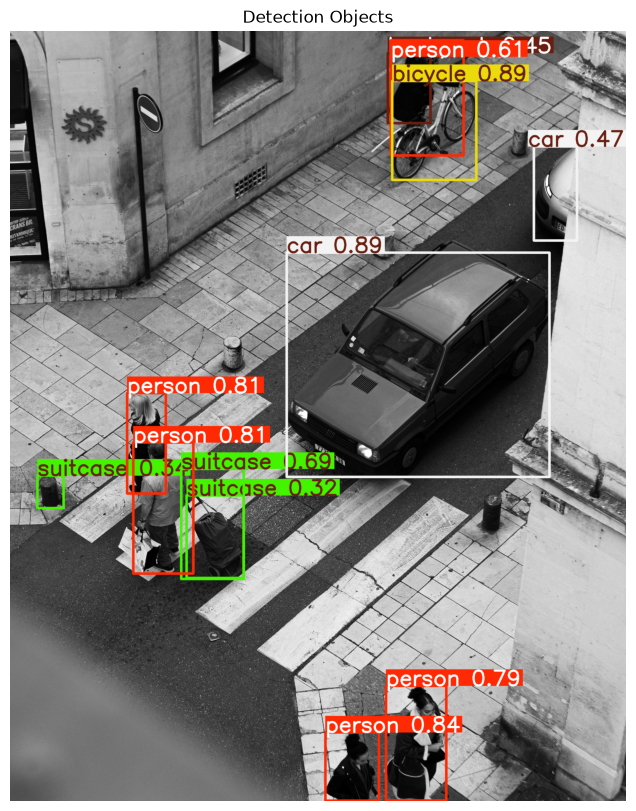

In [4]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
model = YOLO('yolov8m.pt')
results = model('street.jpg')
img_annotated = results[0].plot()
plt.figure(figsize = (10,10))
plt.imshow(img_annotated)
plt.title('Detection Objects')
plt.axis('off')
plt.show()


image 1/1 /home/edward/Python/Java62/python-ai-62/05_yolo_intro/street.jpg: 640x512 5 persons, 1 bicycle, 2 cars, 1 handbag, 1 suitcase, 30.9ms
Speed: 1.9ms preprocess, 30.9ms inference, 3.8ms postprocess per image at shape (1, 3, 640, 512)


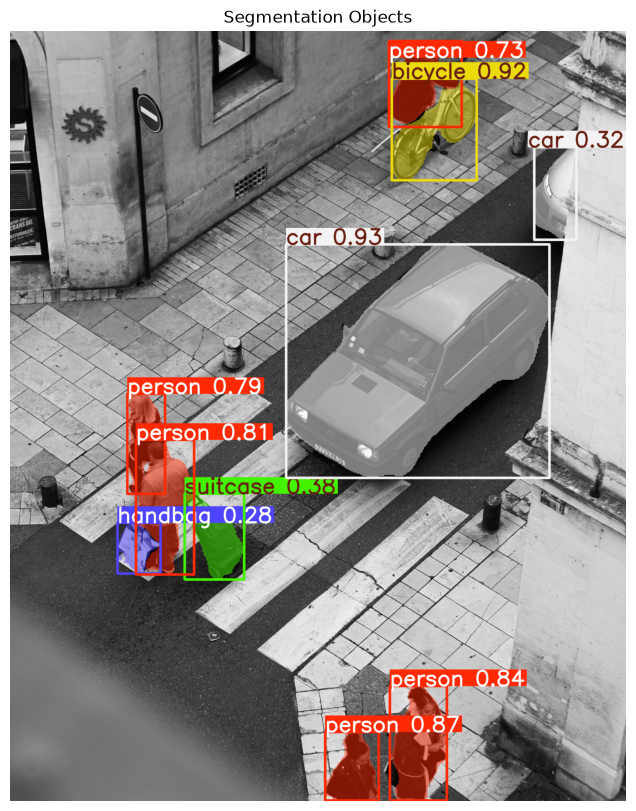

In [5]:
model = YOLO('yolov8m-seg.pt')
results = model('street.jpg')
img_annotated = results[0].plot()
plt.figure(figsize = (10,10))
plt.imshow(img_annotated)
plt.title('Segmentation Objects')
plt.axis('off')
plt.show()


image 1/1 /home/edward/Python/Java62/python-ai-62/05_yolo_intro/street.jpg: 224x224 cab 0.40, streetcar 0.21, trolleybus 0.15, police_van 0.13, garbage_truck 0.02, 6.3ms
Speed: 42.9ms preprocess, 6.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)


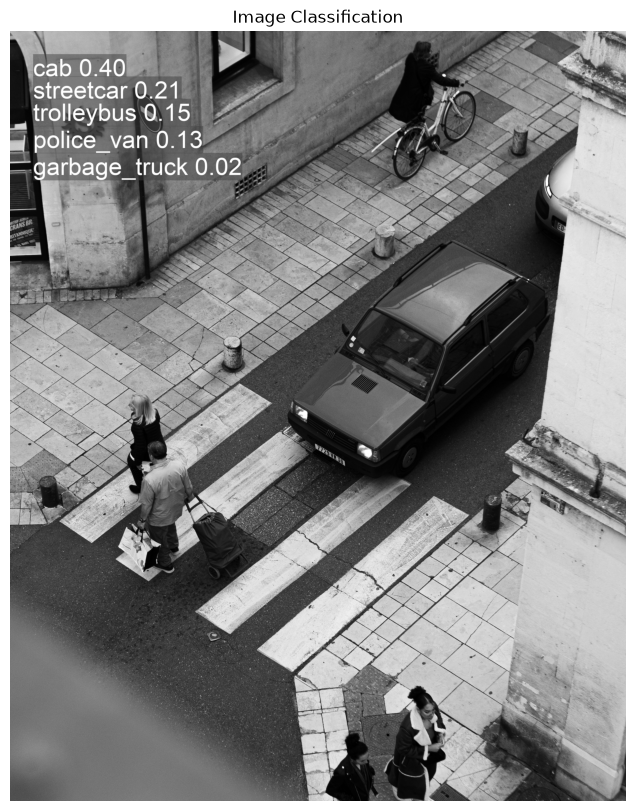

In [8]:
model = YOLO('yolov8l-cls.pt')
results = model('street.jpg')
img_annotated = results[0].plot()
plt.figure(figsize = (10,10))
plt.imshow(img_annotated)
plt.title('Image Classification')
plt.axis('off')
plt.show()

In [15]:
model = YOLO('yolov8m.pt')
results = model('street.jpg')
boxes = results[0].boxes
xyxy = boxes.xyxy.cpu().numpy()
xyxy


image 1/1 /home/edward/Python/Java62/python-ai-62/05_yolo_intro/street.jpg: 640x512 5 persons, 1 bicycle, 2 cars, 1 backpack, 3 suitcases, 23.7ms
Speed: 2.0ms preprocess, 23.7ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 512)


array([[     1437.5,      1151.3,      2802.4,        2317],
       [     1985.2,      259.93,      2422.6,      773.97],
       [       1638,      3643.4,      1916.4,      3998.1],
       [     640.26,      2137.7,      952.16,      2818.5],
       [     608.25,      1880.8,      809.46,      2402.9],
       [     1953.4,      3401.3,        2266,      3997.4],
       [     889.21,      2274.6,      1214.6,      2846.7],
       [     1978.1,      48.688,      2356.8,      646.72],
       [     2721.7,      599.73,      2945.1,      1088.3],
       [     1962.5,      114.76,      2184.1,      478.55],
       [     142.47,      2309.4,       278.6,      2478.4],
       [     917.79,      2412.4,        1214,      2841.5]], dtype=float32)

In [10]:
classes = boxes.cls.cpu().numpy()
classes

array([          2,           1,           0,           0,           0,           0,          28,           0,           2,          24,          28,          28], dtype=float32)

In [11]:
all_names = results[0].names
all_names

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

In [12]:
names = [all_names[i] for i in classes]
names

['car',
 'bicycle',
 'person',
 'person',
 'person',
 'person',
 'suitcase',
 'person',
 'car',
 'backpack',
 'suitcase',
 'suitcase']

In [14]:
confidences = boxes.conf.cpu().numpy()
confidences

array([     0.8916,     0.88991,     0.84174,     0.81323,     0.80559,     0.78548,     0.68594,     0.60912,     0.46597,     0.45095,     0.34281,     0.31607], dtype=float32)

In [16]:
from pandas import DataFrame
df = DataFrame(xyxy, columns=['xmin','ymin','xmax','ymax'])
df

,xmin,ymin,xmax,ymax
0,1437.520020,1151.254028,2802.382568,2316.984131
1,1985.162720,259.930786,2422.572021,773.969543
2,1638.029541,3643.386719,1916.415405,3998.138428
3,640.262329,2137.738525,952.162537,2818.455811
4,608.245667,1880.781494,809.457886,2402.942627
5,1953.413818,3401.280273,2266.005371,3997.421387
6,889.214722,2274.570312,1214.583252,2846.699219
7,1978.075439,48.688316,2356.849609,646.715271
8,2721.662842,599.727661,2945.056885,1088.340576
9,1962.479004,114.757263,2184.140137,478.550903


In [17]:
df['name'] = names
df

,xmin,ymin,xmax,ymax,name
0,1437.520020,1151.254028,2802.382568,2316.984131,car
1,1985.162720,259.930786,2422.572021,773.969543,bicycle
2,1638.029541,3643.386719,1916.415405,3998.138428,person
3,640.262329,2137.738525,952.162537,2818.455811,person
4,608.245667,1880.781494,809.457886,2402.942627,person
5,1953.413818,3401.280273,2266.005371,3997.421387,person
6,889.214722,2274.570312,1214.583252,2846.699219,suitcase
7,1978.075439,48.688316,2356.849609,646.715271,person
8,2721.662842,599.727661,2945.056885,1088.340576,car
9,1962.479004,114.757263,2184.140137,478.550903,backpack


In [18]:
df['confidence'] = confidences
df

,xmin,ymin,xmax,ymax,name,confidence
0,1437.520020,1151.254028,2802.382568,2316.984131,car,0.891599
1,1985.162720,259.930786,2422.572021,773.969543,bicycle,0.889906
2,1638.029541,3643.386719,1916.415405,3998.138428,person,0.841735
3,640.262329,2137.738525,952.162537,2818.455811,person,0.813229
4,608.245667,1880.781494,809.457886,2402.942627,person,0.805587
5,1953.413818,3401.280273,2266.005371,3997.421387,person,0.785476
6,889.214722,2274.570312,1214.583252,2846.699219,suitcase,0.685942
7,1978.075439,48.688316,2356.849609,646.715271,person,0.609116
8,2721.662842,599.727661,2945.056885,1088.340576,car,0.465974
9,1962.479004,114.757263,2184.140137,478.550903,backpack,0.450946
